In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [1]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [6]:
df = pd.read_csv("creditcard.csv")
print(df.head())
print("Shape:", df.shape)



print("\nClass Distribution:")
print(df["Class"].value_counts())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [8]:
X = df.drop(columns=["Class"])
y = df["Class"]


# Missing values
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [9]:

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train.value_counts())




After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [10]:
model = XGBClassifier()

model.fit(X_train, y_train)

print("\nXGBoost training completed.")


y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)


XGBoost training completed.


In [11]:
auc = roc_auc_score(y_test, y_prob)

print("\nROC-AUC:", auc)


# False Positives and False Negatives
cm = confusion_matrix(y_test, y_pred)

print("False Positives:", cm[0][1])
print("False Negatives:", cm[1][0])



ROC-AUC: 0.9829774657471317
False Positives: 34
False Negatives: 13



Top 10 Feature Importances:
V14    0.678984
V4     0.064538
V12    0.031041
V17    0.023056
V1     0.016663
V3     0.015007
V8     0.013564
V13    0.012934
V10    0.011965
V7     0.009623
dtype: float32


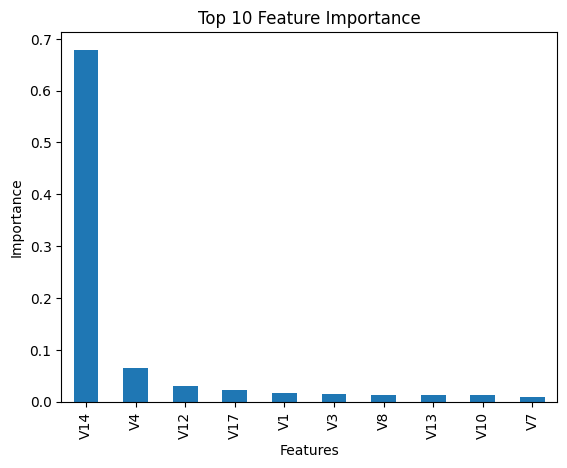

In [12]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 10 Feature Importances:")
print(importance.head(10))


# THE  Feature importance graph
importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()